In [68]:
#from IPython.display import display, Latex

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

## Import all needed libraries and python modules:

In [69]:
from importlib import reload
import functions_spin_p as fy
reload(fy)

import spin_thermoelectric_coefficients as th
reload(th)

<module 'spin_thermoelectric_coefficients' from '/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_model/site_dots/spin_thermoelectric_coefficients.py'>

# Thermoelectric Phenomena based on the Transmission behaviour

The model is based on a laterally coupled double quantum dots chain connected (Horizontally) to electrodes where it is possible to have spin accumulation or not. *The parameters are described for a Tigh Binding Hamiltonian in the Second Quantization. And the remainded parameters are used into the solution for the Hamiltonian using Green Keldysh Functions.* 

In this model it is possible change the Energy Site $(\epsilon^{\sigma}_{i})$ and, by assumption, there is spin degeneration of them $(\Delta=0\Rightarrow\,\epsilon^{\sigma}_{i} = \epsilon_{i})$, the bandwith due to leads contributions in the self energies $(\gamma_{L(R)})$ is parametrized by the polarization due to spin aligment of the leads $(p_{L(R)})$. Additionally, we have the Temperature of the entire system $(T)$ and the hopping of the sites $(V)$.

Under tight binding formulation using second quantization we have the following stuff for the central part:

$$
H_{cen}= \sum_{i}^{2} \vec{c_{i}}^{\dagger} \hat{\epsilon}^{0}_{i} \vec{c_{i}} + \vec{a_{i}}^{\dagger} \hat{\epsilon}^{1}_{i} \vec{a_{i}} + \sum_{i}^{2} \vec{c_{i}}^{\dagger} \hat{\omega} \vec{a_{i}} + h.c. + \sum_{i}^{1} \vec{c_{i}}^{\dagger} \hat{V} \vec{c}_{i+1}+h.c.
$$

Renormalizing the lateral dot sites energies in a new basis, e.g. $\hat{d}_{i}(\hat{d}^{\dagger}_{i})$, we obtain the following:

$$
H_{cen}= \sum_{i}^{2} \vec{d_{i}}^{\dagger} \hat{\varepsilon}_{i} \vec{d_{i}} + \sum_{i}^{1} \vec{d_{i}}^{\dagger} \hat{V} \vec{d}_{i+1}+h.c.
$$

where:

$$
\varepsilon_{i} = \epsilon^{0}_{i} + \frac{\omega^{2}}{E-\epsilon^{1}_{i}}
$$

By assumption we set $\epsilon^{1}_{i}\neq0$ and $\omega\neq0$

In this analysis, the renormalized site energies are degenerated i.e. $\varepsilon^{\sigma}_{i}=\varepsilon_{i}$. So, we can perform analysis based on the variation of the hopping $V$, polarization $p_{L(R)}$. Temperature $T$ is also considered fixed!

# Toy Model:

**Fixed parameters**

$\epsilon^{0}_{1}\,=\,0\,meV$ 

$\epsilon^{0}_{2}\,=\,1\,meV$ 

$\epsilon^{1}_{1}\,=\,2\,meV$ 

$\epsilon^{0}_{1}\,=\,3\,meV$ 

$\omega = 0.5$

$\gamma\,=\,1\,meV $

$T= 1\,K$ it is recommended take values between 1 and 10  

$E\,=\,[-2,6]$ $meV$ 

$\mu\,=\,[-2,6]$ $meV$

In [70]:
#Energy axis

energy_axis = np.arange(-2, 6 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

#Gamma i.e. width parameter
gamma = 1 #meV
print("The width is:",gamma,"meV")


#Site energies:
e_01 = 0 #meV
e_02 = 1 #meV
e_11 = 2
e_12 = 3

#Hopping of the lateral dots:
om = 0.5

#Renormalized site energies array:
e_ren_1 = np.array([e_01,e_11, om])

e_ren_2 = np.array([e_02, e_12, om])

# print("The site (spin independent) energies are:", \
#       e_1," meV and",e_2," meV")

Energy axis is [-2.00000000e+00 -1.99000000e+00 -1.98000000e+00 -1.97000000e+00
 -1.96000000e+00 -1.95000000e+00 -1.94000000e+00 -1.93000000e+00
 -1.92000000e+00 -1.91000000e+00 -1.90000000e+00 -1.89000000e+00
 -1.88000000e+00 -1.87000000e+00 -1.86000000e+00 -1.85000000e+00
 -1.84000000e+00 -1.83000000e+00 -1.82000000e+00 -1.81000000e+00
 -1.80000000e+00 -1.79000000e+00 -1.78000000e+00 -1.77000000e+00
 -1.76000000e+00 -1.75000000e+00 -1.74000000e+00 -1.73000000e+00
 -1.72000000e+00 -1.71000000e+00 -1.70000000e+00 -1.69000000e+00
 -1.68000000e+00 -1.67000000e+00 -1.66000000e+00 -1.65000000e+00
 -1.64000000e+00 -1.63000000e+00 -1.62000000e+00 -1.61000000e+00
 -1.60000000e+00 -1.59000000e+00 -1.58000000e+00 -1.57000000e+00
 -1.56000000e+00 -1.55000000e+00 -1.54000000e+00 -1.53000000e+00
 -1.52000000e+00 -1.51000000e+00 -1.50000000e+00 -1.49000000e+00
 -1.48000000e+00 -1.47000000e+00 -1.46000000e+00 -1.45000000e+00
 -1.44000000e+00 -1.43000000e+00 -1.42000000e+00 -1.41000000e+00
 -1.400000

In [71]:
#More Parameters
temperature = 1 #Kelvin
print("T is:", temperature,"Kelvin")

fermi_axis = np.arange(-2, 6 + 0.01, 0.01) #meV
print("Fermi Energy axis is", fermi_axis,"meV")

T is: 1 Kelvin
Fermi Energy axis is [-2.00000000e+00 -1.99000000e+00 -1.98000000e+00 -1.97000000e+00
 -1.96000000e+00 -1.95000000e+00 -1.94000000e+00 -1.93000000e+00
 -1.92000000e+00 -1.91000000e+00 -1.90000000e+00 -1.89000000e+00
 -1.88000000e+00 -1.87000000e+00 -1.86000000e+00 -1.85000000e+00
 -1.84000000e+00 -1.83000000e+00 -1.82000000e+00 -1.81000000e+00
 -1.80000000e+00 -1.79000000e+00 -1.78000000e+00 -1.77000000e+00
 -1.76000000e+00 -1.75000000e+00 -1.74000000e+00 -1.73000000e+00
 -1.72000000e+00 -1.71000000e+00 -1.70000000e+00 -1.69000000e+00
 -1.68000000e+00 -1.67000000e+00 -1.66000000e+00 -1.65000000e+00
 -1.64000000e+00 -1.63000000e+00 -1.62000000e+00 -1.61000000e+00
 -1.60000000e+00 -1.59000000e+00 -1.58000000e+00 -1.57000000e+00
 -1.56000000e+00 -1.55000000e+00 -1.54000000e+00 -1.53000000e+00
 -1.52000000e+00 -1.51000000e+00 -1.50000000e+00 -1.49000000e+00
 -1.48000000e+00 -1.47000000e+00 -1.46000000e+00 -1.45000000e+00
 -1.44000000e+00 -1.43000000e+00 -1.42000000e+00 -1.41

## Reference case:

If $V = 0\,$, we don't have any quantum interference! Additionally, if $p_{L(R)}=0$ we have the same width (i.e. same particle lifetime) per spin channel! 

In [72]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

# Hopping
v = 0

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [73]:
#Transmission axis

no_quantum_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
no_quantum_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

#Thermopower
s_no_quantum = th.S(fermi_axis, temperature, energy_axis, p_R, p_R, gamma, Hamiltonian, site_energies)
s_no_quantum_u = th.S_up(fermi_axis, temperature, energy_axis, p_R, p_R, gamma, Hamiltonian, site_energies)
s_no_quantum_d = th.S_down(fermi_axis, temperature, energy_axis, p_R, p_R, gamma, Hamiltonian, site_energies)

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:50: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


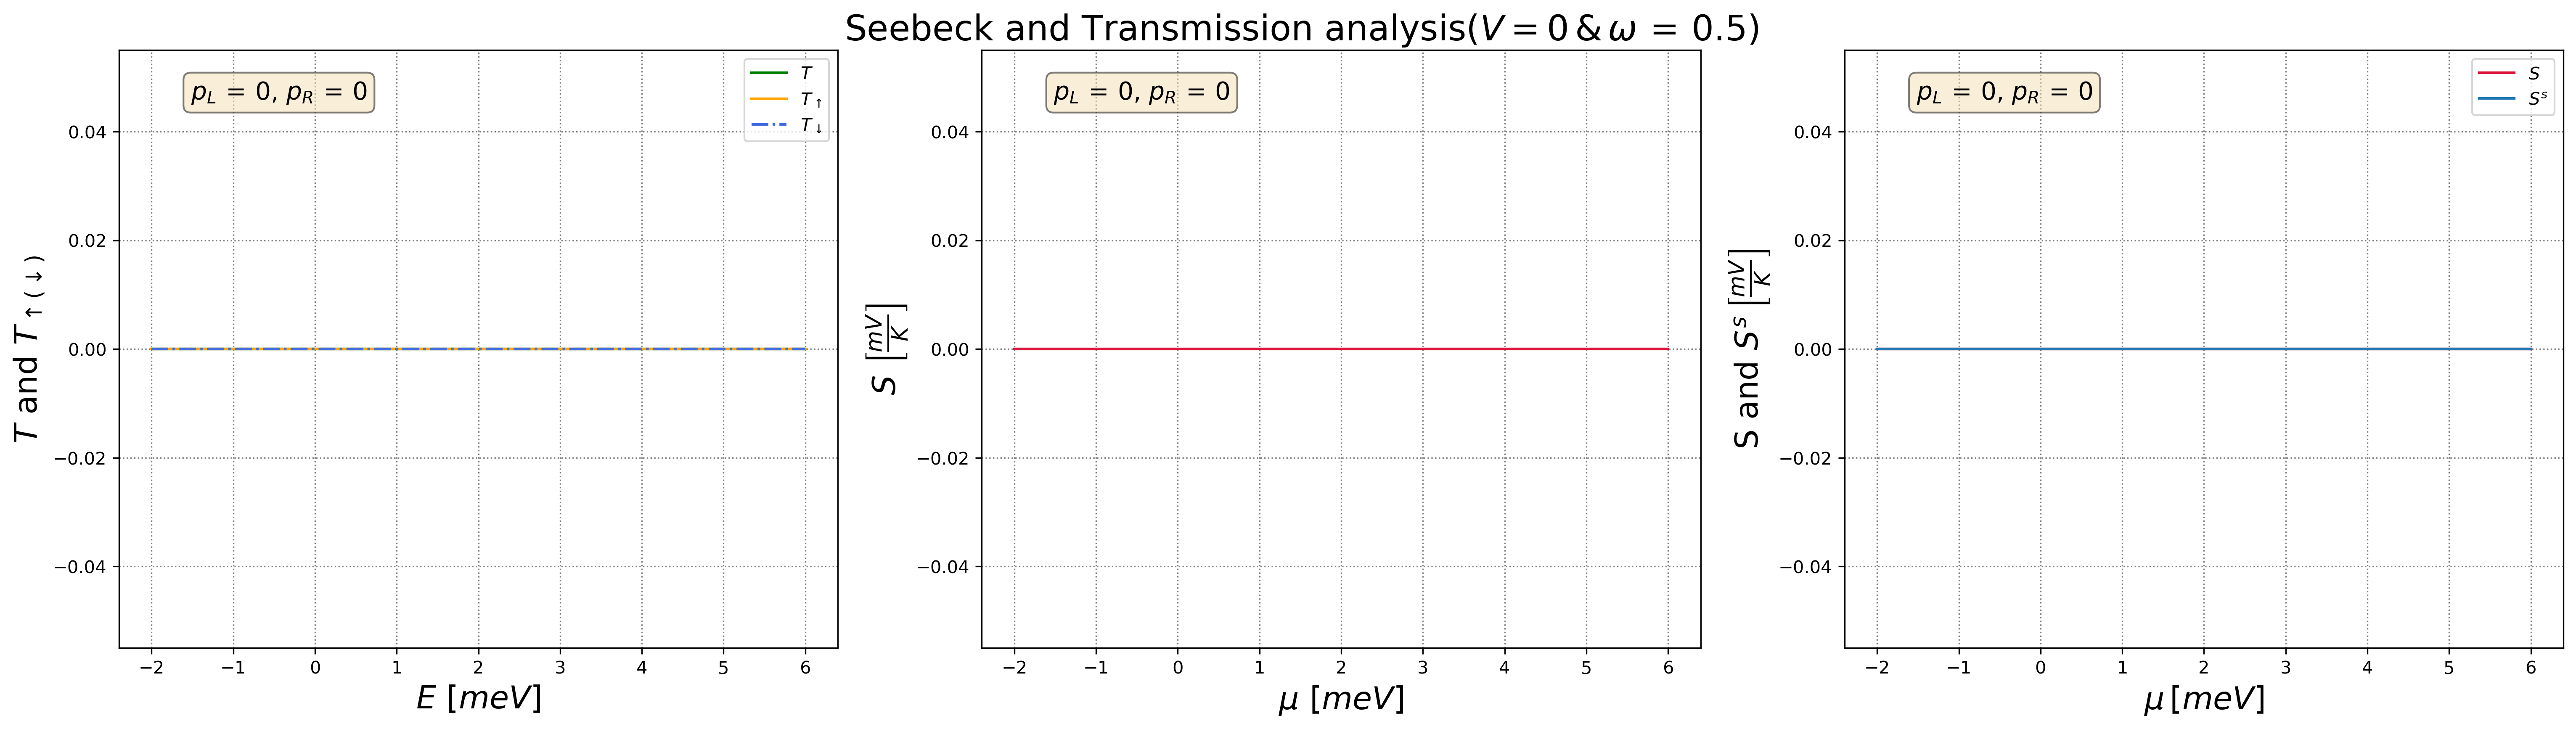

In [74]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(25,6), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(1, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Transmission Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, no_quantum_u + no_quantum_d, "g", label= r"$T$")
ax1.plot(energy_axis, no_quantum_u, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax1.plot(energy_axis, no_quantum_d, "#4169E1", linestyle="-.", label= r"$T_{\downarrow}$")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax1.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, s_no_quantum, "#DC143C")
ax2.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax3.grid(linestyle=':', color='grey')
# ax3.plot(fermi_axis, s_no_quantum_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax3.plot(fermi_axis, s_no_quantum_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax3.plot(fermi_axis, -(1/2)*(s_no_quantum_u+s_no_quantum_d), "#DC143C", label=r"$S$", linestyle="-")
ax3.plot(fermi_axis, -(1/2)*(s_no_quantum_u-s_no_quantum_d), "#1f77b4", label = r"$S^{s}$", linestyle = "-" )
ax3.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax3.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax3.legend( loc='upper right')  

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck and Transmission analysis"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('reference.jpg')

## Case 1: $V=0.5$ and for different polarization configurations

In [75]:
# Hopping
v = 0.5

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0. +0.j 0. +0.j 0.5+0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0. +0.j 0. +0.j]]


In [76]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

#Thermopower
s_transmission = th.S(fermi_axis, temperature, energy_axis, p_L, p_R, gamma, Hamiltonian, site_energies)
s_transmission_u = th.S_up(fermi_axis, temperature, energy_axis, p_L, p_R, gamma, Hamiltonian, site_energies)
s_transmission_d = th.S_down(fermi_axis, temperature, energy_axis, p_L, p_R, gamma, Hamiltonian, site_energies)

In [77]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]

#Thermopower
s_transmission_1 = th.S(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
s_transmission_u_1 = th.S_up(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
s_transmission_d_1 = th.S_down(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)

In [78]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]

#Thermopower
s_transmission_2 = th.S(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
s_transmission_u_2 = th.S_up(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
s_transmission_d_2 = th.S_down(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:122: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


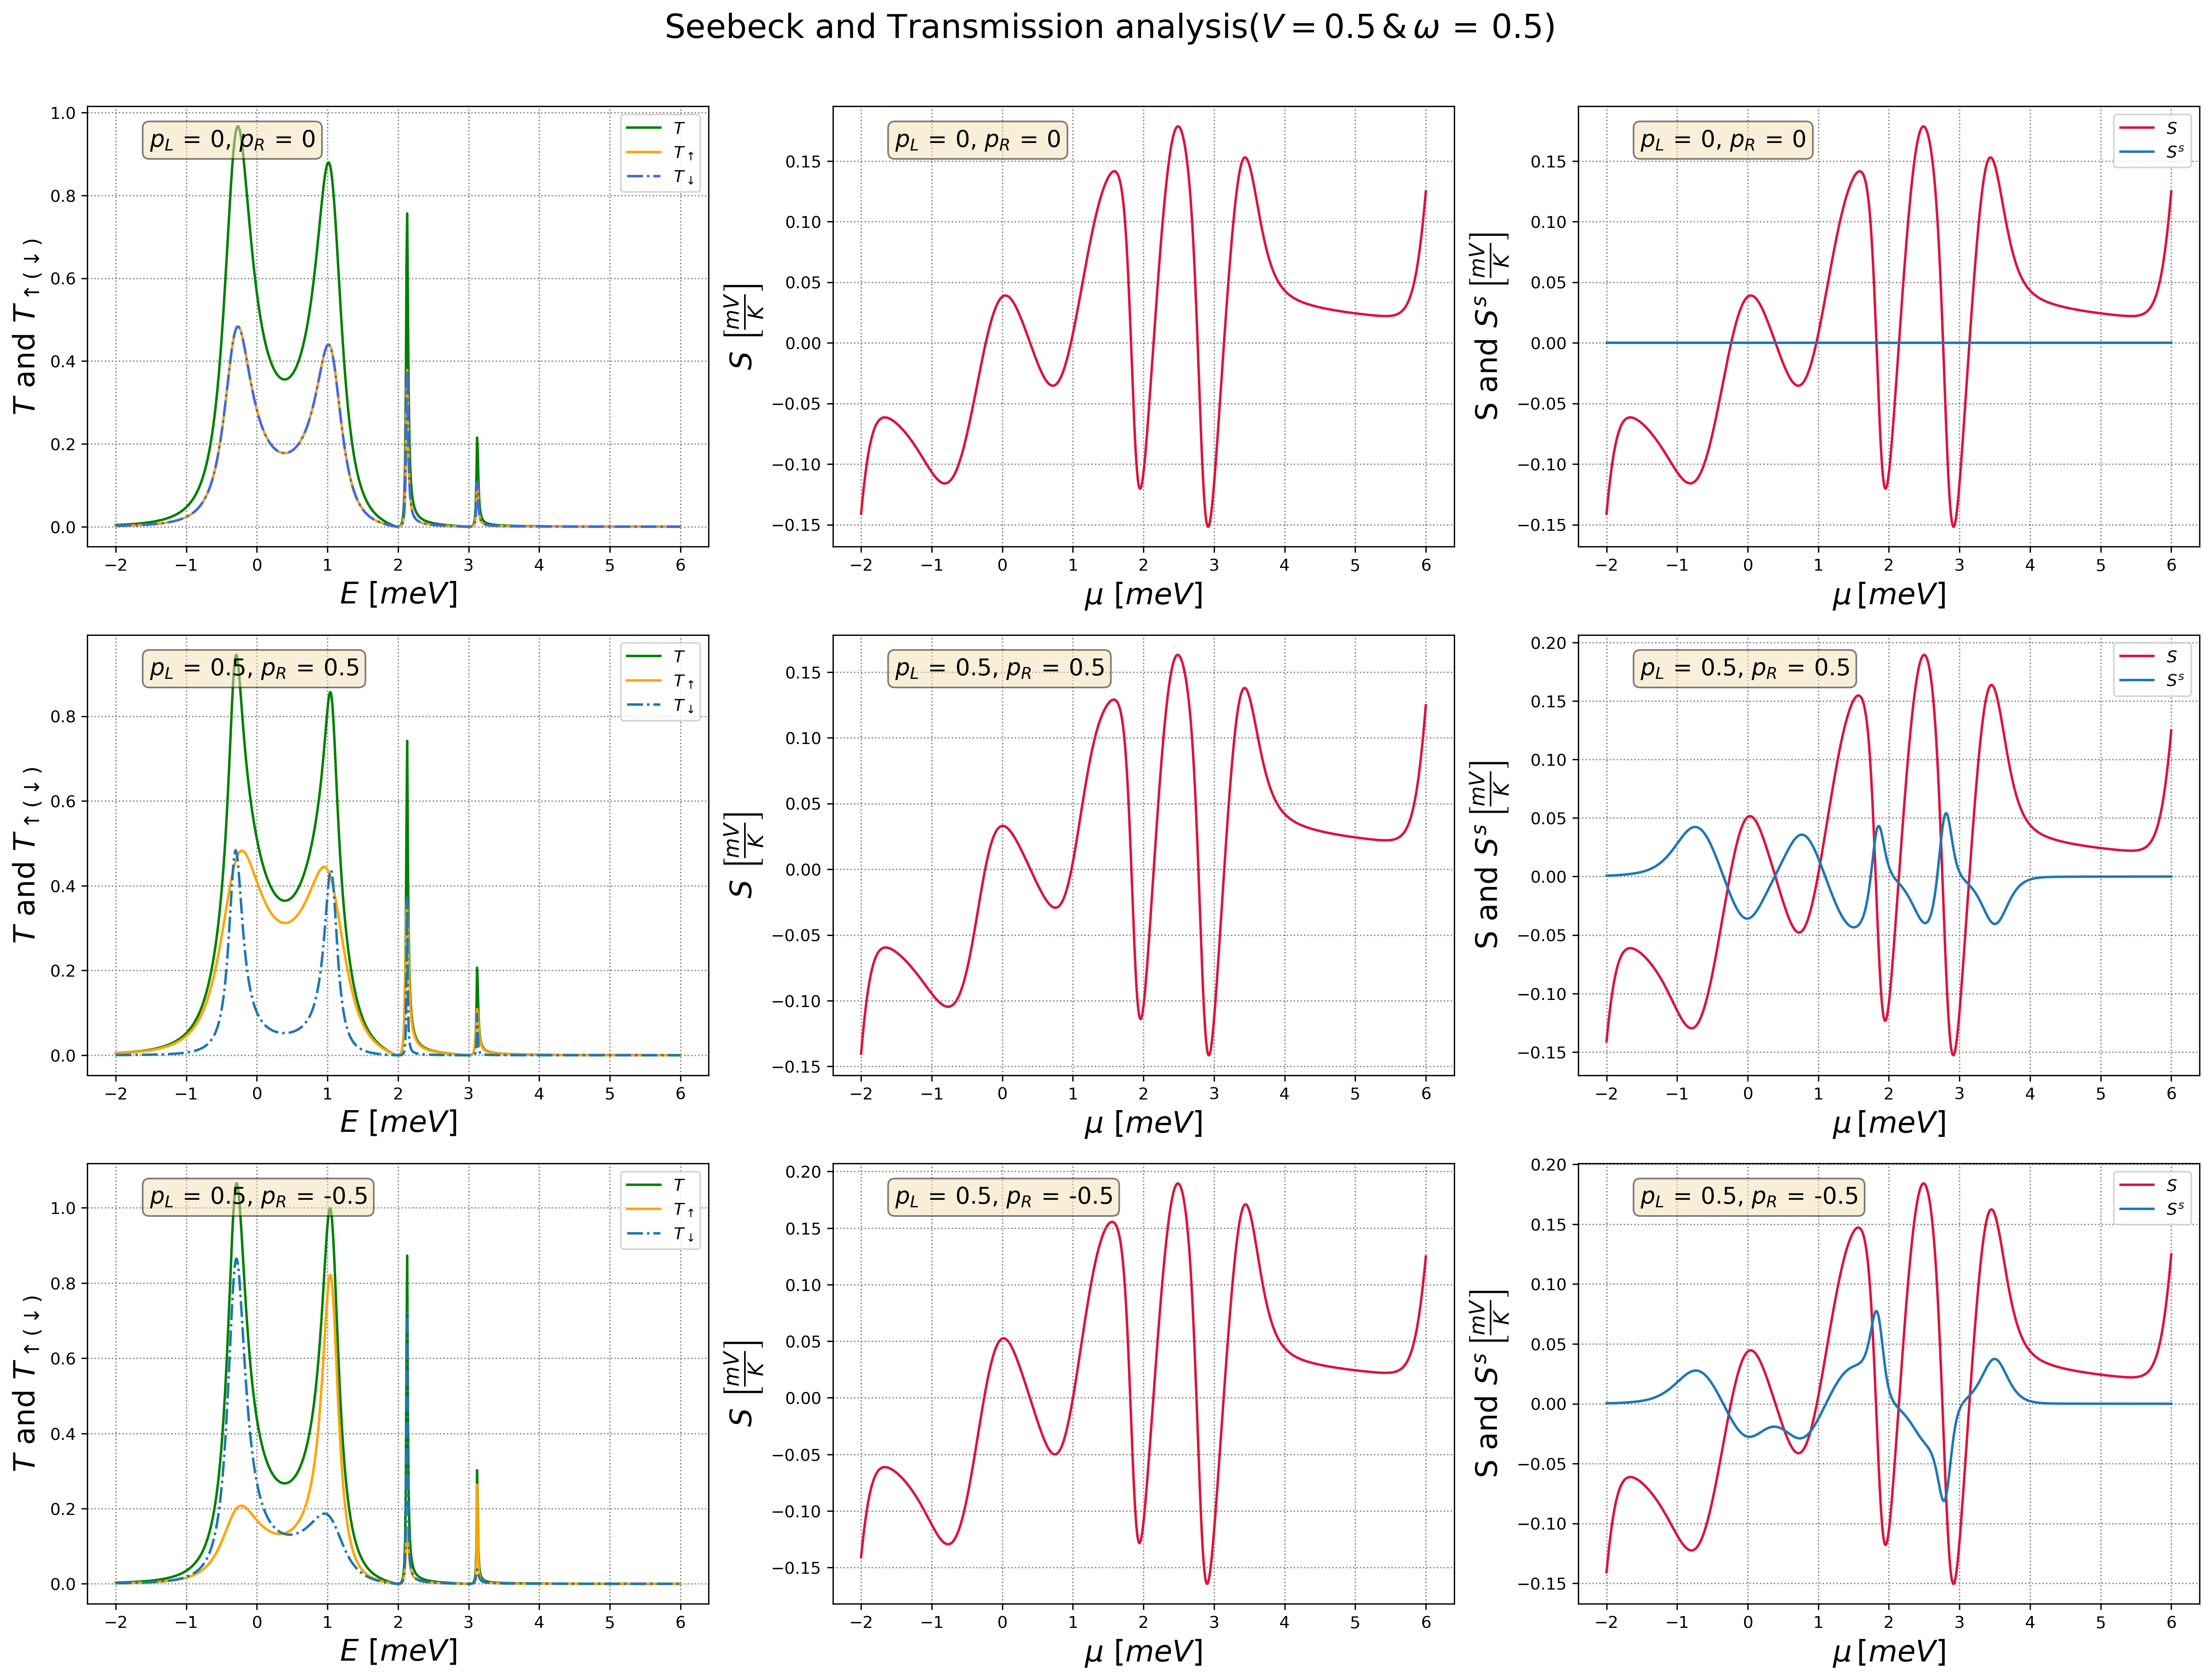

In [79]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])


# Transmission Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u + transmission_d, "g", label= r"$T$")
ax1.plot(energy_axis, transmission_u, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax1.plot(energy_axis, transmission_d, "#4169E1", linestyle="-.", label= r"$T_{\downarrow}$")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax1.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, s_transmission, "#DC143C")
ax2.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax3.grid(linestyle=':', color='grey')
# ax3.plot(fermi_axis, s_no_quantum_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax3.plot(fermi_axis, s_no_quantum_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax3.plot(fermi_axis, -(1/2)*(s_transmission_u+s_transmission_d), "#DC143C", label=r"$S$", linestyle="-")
ax3.plot(fermi_axis, -(1/2)*(s_transmission_u-s_transmission_d), "#1f77b4", label = r"$S^{s}$", linestyle = "-" )
ax3.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax3.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax3.legend( loc='upper right')  

# QUANTUM INTERFERENCE

# Total Transmission Plot
ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1 + transmission_d_1, "g", label= r"$T$")
ax4.plot(energy_axis, transmission_u_1, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax4.plot(energy_axis, transmission_d_1, "#1f77b4", linestyle="-.", label= r"$T_{\downarrow}$")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax4.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax5.grid(linestyle=':', color='grey')
ax5.plot(fermi_axis, s_transmission_1, "#DC143C")
ax5.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax6.grid(linestyle=':', color='grey')
# ax6.plot(fermi_axis, s_transmission_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax6.plot(fermi_axis, s_transmission_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax6.plot(fermi_axis, -(1/2)*(s_transmission_u_1 + s_transmission_d_1), "#DC143C", label=r"$S$", linestyle="-")
ax6.plot(fermi_axis, -(1/2)*(s_transmission_u_1 - s_transmission_d_1), "#1f77b4", label = r"$S^{s}$", linestyle="-" )
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax6.legend( loc='upper right')

# Total Transmission Plot
ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2 + transmission_d_2, "g", label= r"$T$")
ax7.plot(energy_axis, transmission_u_2, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax7.plot(energy_axis, transmission_d_2, "#1f77b4", linestyle="-.", label= r"$T_{\downarrow}$")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(fermi_axis, s_transmission_2, "#DC143C")
ax8.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
# ax9.plot(fermi_axis, s_fano_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax9.plot(fermi_axis, s_fano_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax9.plot(fermi_axis, -(1/2)*(s_transmission_u_2 + s_transmission_d_2), "#DC143C", label=r"$S$", linestyle="-")
ax9.plot(fermi_axis, -(1/2)*(s_transmission_u_2 - s_transmission_d_2), "#1f77b4", label = r"$S^{s}$", linestyle="-" )
ax9.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax9.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax9.legend( loc='upper right')


# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck and Transmission analysis"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('seebeck_analysis_1.jpg')

## Case 1: $V=1$ and for different polarization configurations

In [80]:
# Hopping
v = 1

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


In [81]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

#Thermopower
s_transmission = th.S(fermi_axis, temperature, energy_axis, p_L, p_R, gamma, Hamiltonian, site_energies)
s_transmission_u = th.S_up(fermi_axis, temperature, energy_axis, p_L, p_R, gamma, Hamiltonian, site_energies)
s_transmission_d = th.S_down(fermi_axis, temperature, energy_axis, p_L, p_R, gamma, Hamiltonian, site_energies)

In [82]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]

#Thermopower
s_transmission_1 = th.S(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
s_transmission_u_1 = th.S_up(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
s_transmission_d_1 = th.S_down(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)

In [83]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]

#Thermopower
s_transmission_2 = th.S(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
s_transmission_u_2 = th.S_up(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
s_transmission_d_2 = th.S_down(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:122: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


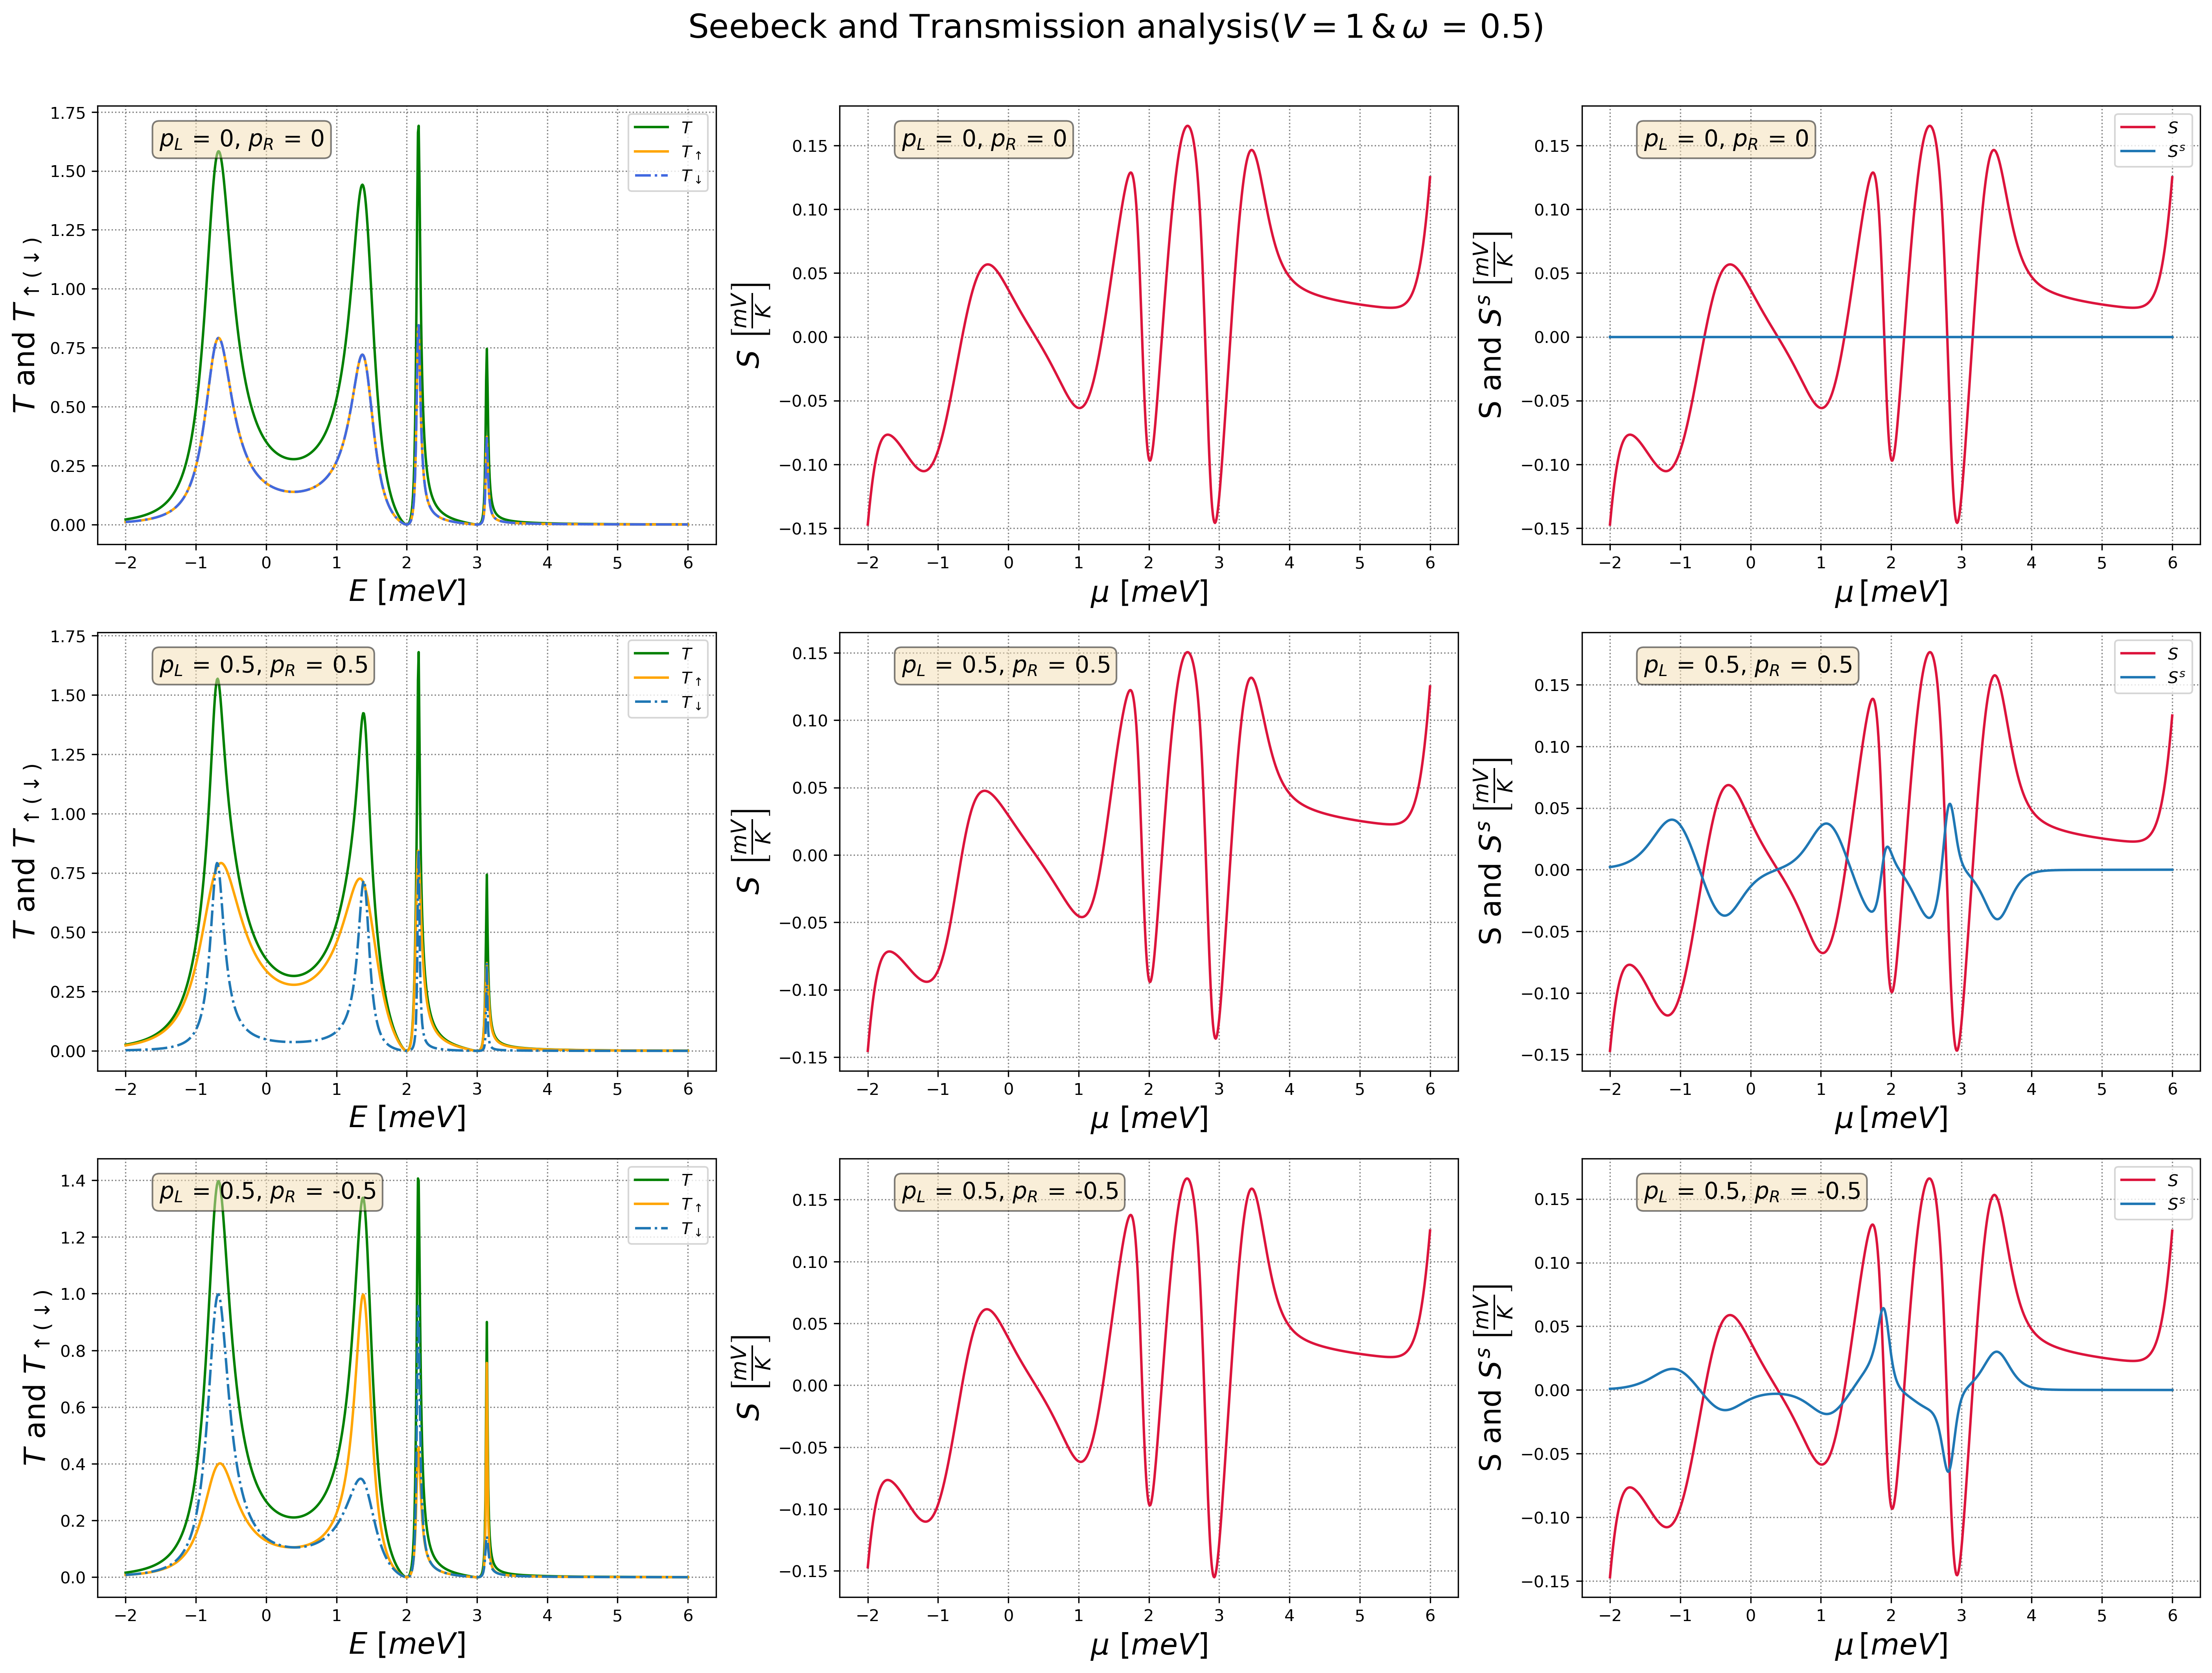

In [84]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])


# Transmission Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u + transmission_d, "g", label= r"$T$")
ax1.plot(energy_axis, transmission_u, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax1.plot(energy_axis, transmission_d, "#4169E1", linestyle="-.", label= r"$T_{\downarrow}$")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax1.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, s_transmission, "#DC143C")
ax2.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax3.grid(linestyle=':', color='grey')
# ax3.plot(fermi_axis, s_no_quantum_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax3.plot(fermi_axis, s_no_quantum_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax3.plot(fermi_axis, -(1/2)*(s_transmission_u+s_transmission_d), "#DC143C", label=r"$S$", linestyle="-")
ax3.plot(fermi_axis, -(1/2)*(s_transmission_u-s_transmission_d), "#1f77b4", label = r"$S^{s}$", linestyle = "-" )
ax3.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax3.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax3.legend( loc='upper right')  

# QUANTUM INTERFERENCE

# Total Transmission Plot
ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1 + transmission_d_1, "g", label= r"$T$")
ax4.plot(energy_axis, transmission_u_1, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax4.plot(energy_axis, transmission_d_1, "#1f77b4", linestyle="-.", label= r"$T_{\downarrow}$")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax4.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax5.grid(linestyle=':', color='grey')
ax5.plot(fermi_axis, s_transmission_1, "#DC143C")
ax5.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax6.grid(linestyle=':', color='grey')
# ax6.plot(fermi_axis, s_transmission_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax6.plot(fermi_axis, s_transmission_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax6.plot(fermi_axis, -(1/2)*(s_transmission_u_1 + s_transmission_d_1), "#DC143C", label=r"$S$", linestyle="-")
ax6.plot(fermi_axis, -(1/2)*(s_transmission_u_1 - s_transmission_d_1), "#1f77b4", label = r"$S^{s}$", linestyle="-" )
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax6.legend( loc='upper right')

# Total Transmission Plot
ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2 + transmission_d_2, "g", label= r"$T$")
ax7.plot(energy_axis, transmission_u_2, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax7.plot(energy_axis, transmission_d_2, "#1f77b4", linestyle="-.", label= r"$T_{\downarrow}$")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(fermi_axis, s_transmission_2, "#DC143C")
ax8.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
# ax9.plot(fermi_axis, s_fano_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax9.plot(fermi_axis, s_fano_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax9.plot(fermi_axis, -(1/2)*(s_transmission_u_2 + s_transmission_d_2), "#DC143C", label=r"$S$", linestyle="-")
ax9.plot(fermi_axis, -(1/2)*(s_transmission_u_2 - s_transmission_d_2), "#1f77b4", label = r"$S^{s}$", linestyle="-" )
ax9.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax9.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax9.legend( loc='upper right')


# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck and Transmission analysis"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('seebeck_analysis_2.jpg')

## Now changing the temperature!


In [91]:
#More Parameters
temperature = 0.5 #Kelvin
print("T is:", temperature,"Kelvin")

fermi_axis = np.arange(-2, 6 + 0.01, 0.01) #meV
print("Fermi Energy axis is", fermi_axis,"meV")

T is: 0.5 Kelvin
Fermi Energy axis is [-2.00000000e+00 -1.99000000e+00 -1.98000000e+00 -1.97000000e+00
 -1.96000000e+00 -1.95000000e+00 -1.94000000e+00 -1.93000000e+00
 -1.92000000e+00 -1.91000000e+00 -1.90000000e+00 -1.89000000e+00
 -1.88000000e+00 -1.87000000e+00 -1.86000000e+00 -1.85000000e+00
 -1.84000000e+00 -1.83000000e+00 -1.82000000e+00 -1.81000000e+00
 -1.80000000e+00 -1.79000000e+00 -1.78000000e+00 -1.77000000e+00
 -1.76000000e+00 -1.75000000e+00 -1.74000000e+00 -1.73000000e+00
 -1.72000000e+00 -1.71000000e+00 -1.70000000e+00 -1.69000000e+00
 -1.68000000e+00 -1.67000000e+00 -1.66000000e+00 -1.65000000e+00
 -1.64000000e+00 -1.63000000e+00 -1.62000000e+00 -1.61000000e+00
 -1.60000000e+00 -1.59000000e+00 -1.58000000e+00 -1.57000000e+00
 -1.56000000e+00 -1.55000000e+00 -1.54000000e+00 -1.53000000e+00
 -1.52000000e+00 -1.51000000e+00 -1.50000000e+00 -1.49000000e+00
 -1.48000000e+00 -1.47000000e+00 -1.46000000e+00 -1.45000000e+00
 -1.44000000e+00 -1.43000000e+00 -1.42000000e+00 -1.

In [92]:
# Hopping
v = 1

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


In [93]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

#Thermopower
s_transmission = th.S(fermi_axis, temperature, energy_axis, p_L, p_R, gamma, Hamiltonian, site_energies)
s_transmission_u = th.S_up(fermi_axis, temperature, energy_axis, p_L, p_R, gamma, Hamiltonian, site_energies)
s_transmission_d = th.S_down(fermi_axis, temperature, energy_axis, p_L, p_R, gamma, Hamiltonian, site_energies)

In [94]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]

#Thermopower
s_transmission_1 = th.S(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
s_transmission_u_1 = th.S_up(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
s_transmission_d_1 = th.S_down(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)

In [95]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]

#Thermopower
s_transmission_2 = th.S(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
s_transmission_u_2 = th.S_up(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
s_transmission_d_2 = th.S_down(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:122: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


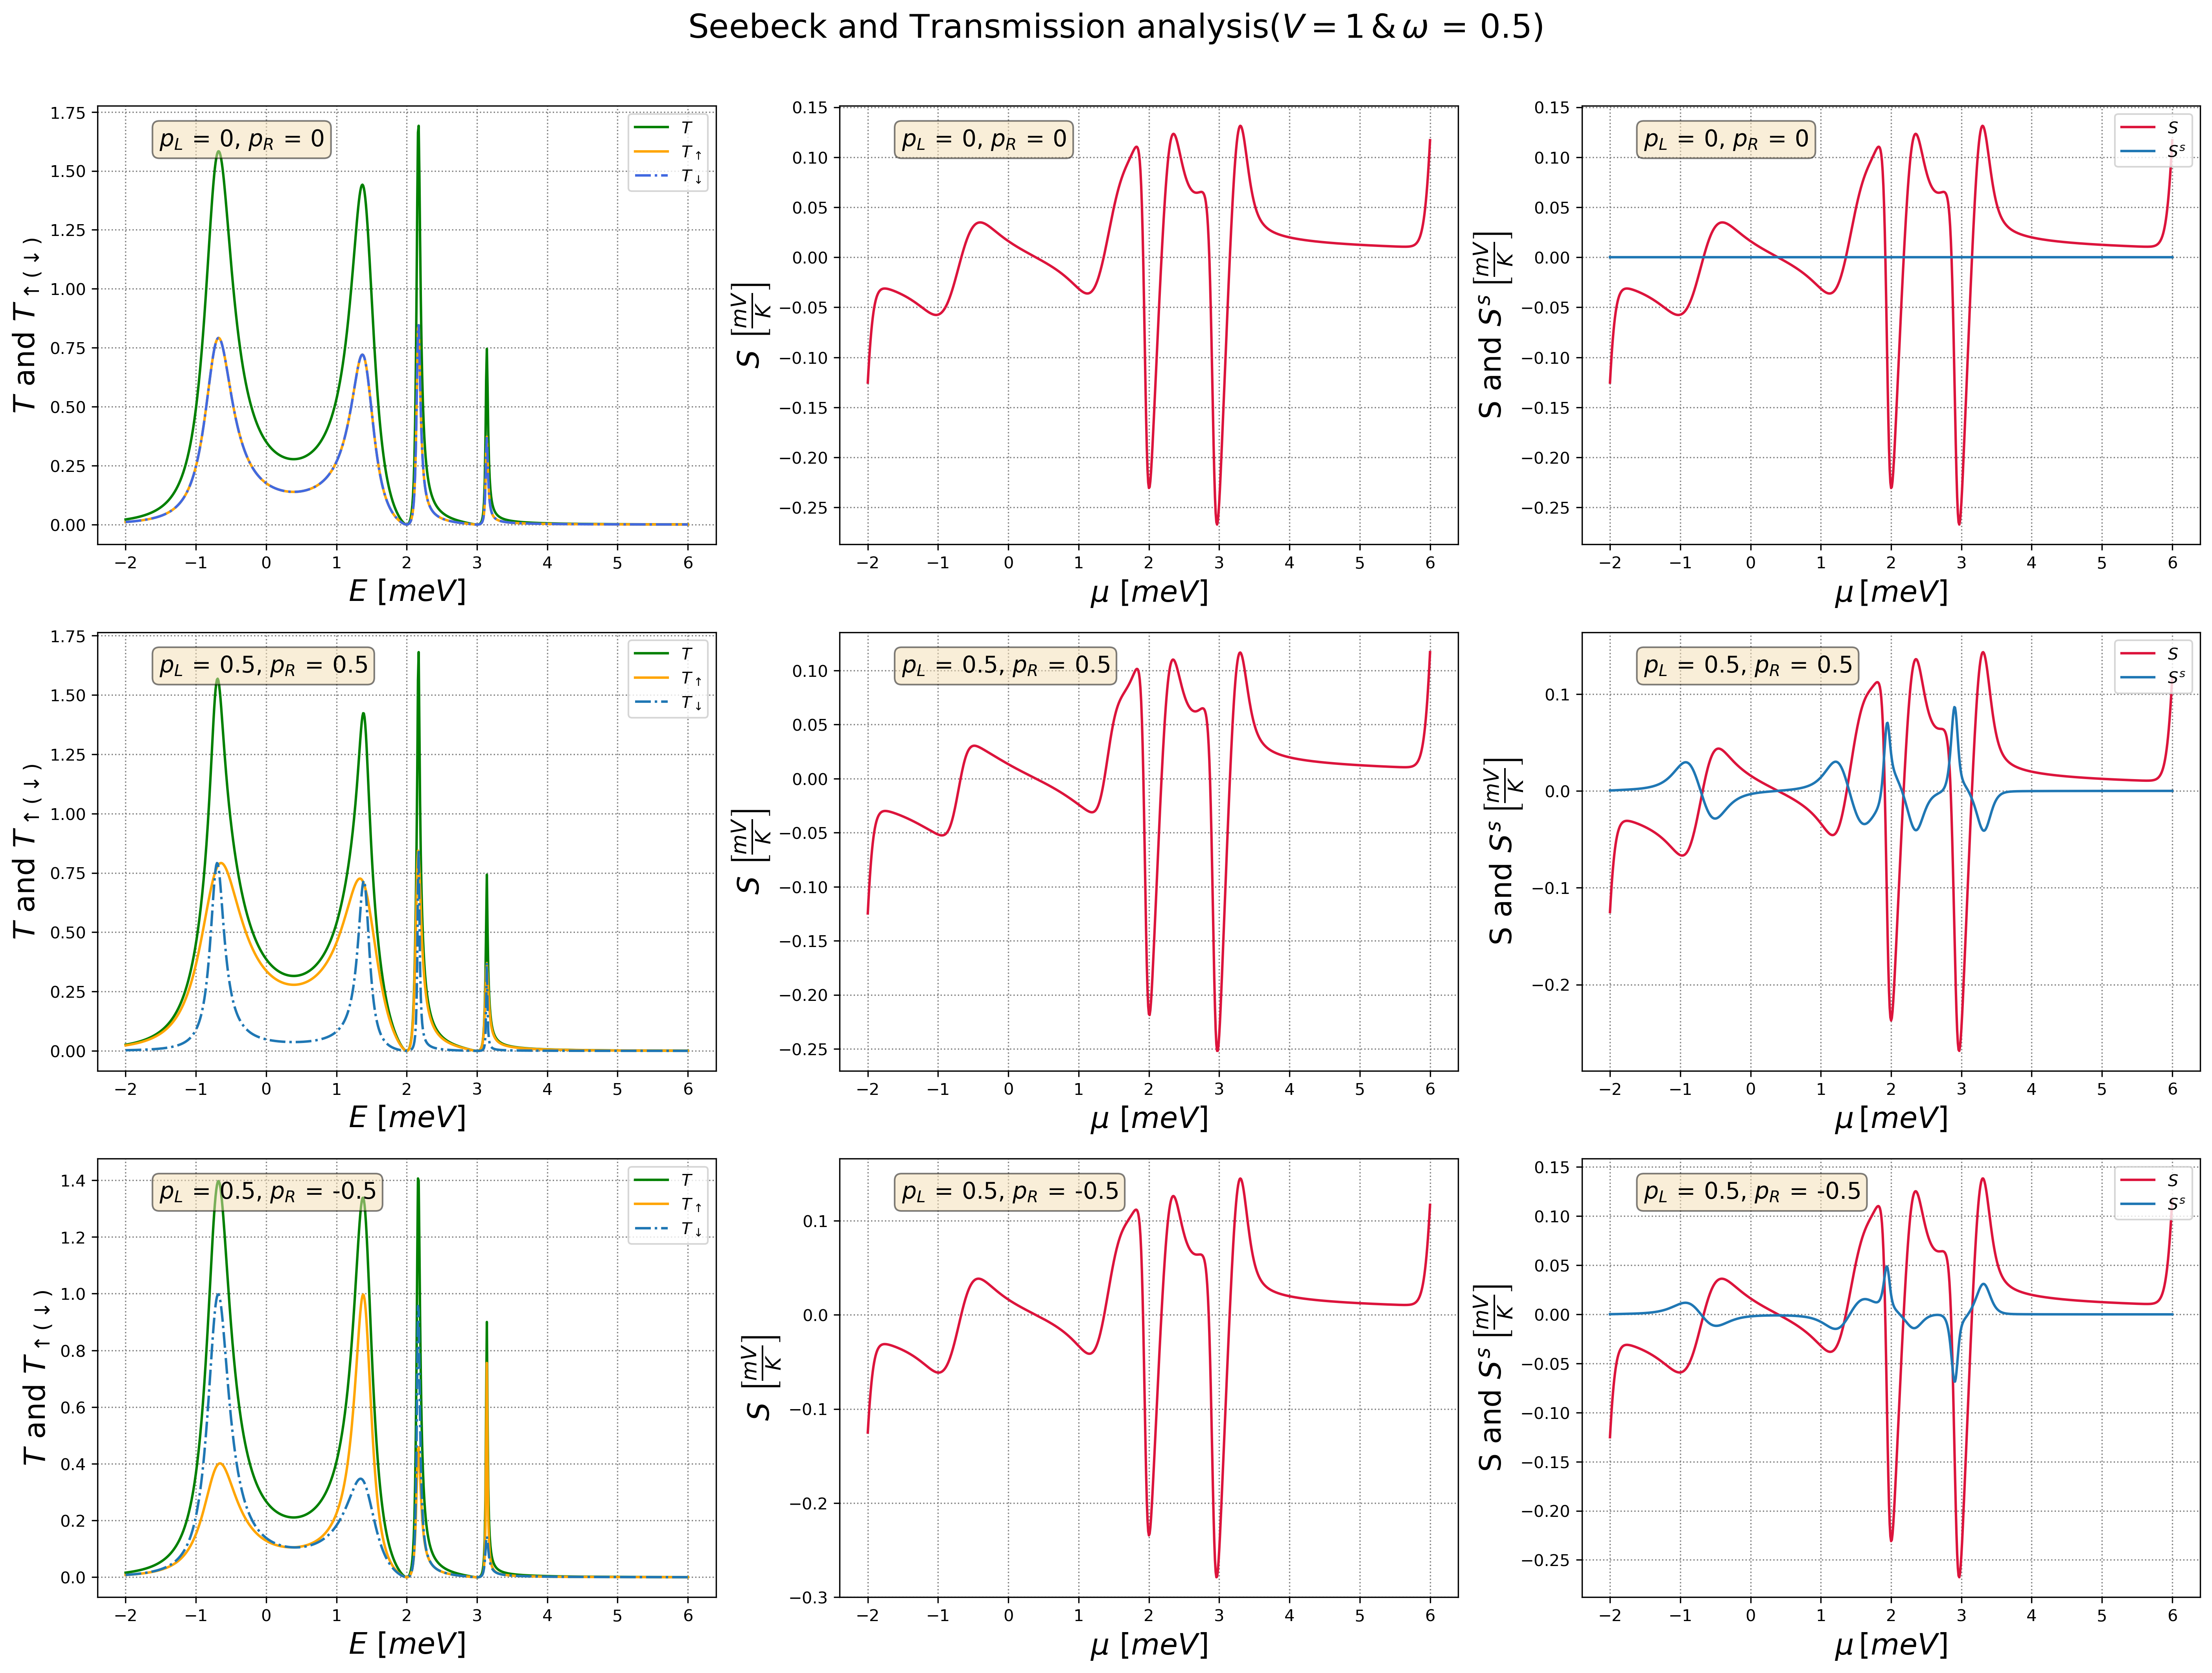

In [96]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])


# Transmission Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u + transmission_d, "g", label= r"$T$")
ax1.plot(energy_axis, transmission_u, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax1.plot(energy_axis, transmission_d, "#4169E1", linestyle="-.", label= r"$T_{\downarrow}$")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax1.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, s_transmission, "#DC143C")
ax2.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax3.grid(linestyle=':', color='grey')
# ax3.plot(fermi_axis, s_no_quantum_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax3.plot(fermi_axis, s_no_quantum_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax3.plot(fermi_axis, -(1/2)*(s_transmission_u+s_transmission_d), "#DC143C", label=r"$S$", linestyle="-")
ax3.plot(fermi_axis, -(1/2)*(s_transmission_u-s_transmission_d), "#1f77b4", label = r"$S^{s}$", linestyle = "-" )
ax3.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax3.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax3.legend( loc='upper right')  

# QUANTUM INTERFERENCE

# Total Transmission Plot
ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1 + transmission_d_1, "g", label= r"$T$")
ax4.plot(energy_axis, transmission_u_1, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax4.plot(energy_axis, transmission_d_1, "#1f77b4", linestyle="-.", label= r"$T_{\downarrow}$")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax4.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax5.grid(linestyle=':', color='grey')
ax5.plot(fermi_axis, s_transmission_1, "#DC143C")
ax5.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax6.grid(linestyle=':', color='grey')
# ax6.plot(fermi_axis, s_transmission_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax6.plot(fermi_axis, s_transmission_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax6.plot(fermi_axis, -(1/2)*(s_transmission_u_1 + s_transmission_d_1), "#DC143C", label=r"$S$", linestyle="-")
ax6.plot(fermi_axis, -(1/2)*(s_transmission_u_1 - s_transmission_d_1), "#1f77b4", label = r"$S^{s}$", linestyle="-" )
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax6.legend( loc='upper right')

# Total Transmission Plot
ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2 + transmission_d_2, "g", label= r"$T$")
ax7.plot(energy_axis, transmission_u_2, "#FFA500", linestyle="-", label= r"$T_{\uparrow}$" )
ax7.plot(energy_axis, transmission_d_2, "#1f77b4", linestyle="-.", label= r"$T_{\downarrow}$")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r"$T$" +r' and $T_{\uparrow(\downarrow)}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(fermi_axis, s_transmission_2, "#DC143C")
ax8.set_xlabel(r'$\mu\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$S\,\,\left[ \frac{mV}{K} \right]$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
# ax9.plot(fermi_axis, s_fano_u, "#FF6347", label=r"$S^{\uparrow}$", linestyle=":", linewidth=3.0)
# ax9.plot(fermi_axis, s_fano_d, "#1f77b4", label = r"$S^{\downarrow}$", linestyle = "-.", linewidth=2.0 )
ax9.plot(fermi_axis, -(1/2)*(s_transmission_u_2 + s_transmission_d_2), "#DC143C", label=r"$S$", linestyle="-")
ax9.plot(fermi_axis, -(1/2)*(s_transmission_u_2 - s_transmission_d_2), "#1f77b4", label = r"$S^{s}$", linestyle="-" )
ax9.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax9.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$',fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax9.legend( loc='upper right')


# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck and Transmission analysis"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

#fig.savefig('seebeck_reference.jpg')